In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Model
from tensorflow.keras.applications import ResNet50 # Import ResNet50
from tensorflow.keras.layers import Conv2DTranspose, concatenate, Conv2D, Dropout # Import layers
from tensorflow.keras.regularizers import l2 # Import l2 regularizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm
import kagglehub

In [ ]:
path = kagglehub.dataset_download("samiwood/synthetic-flood-imagery-for-image-segmentation")
print("Dataset downloaded at:", path)

Dataset downloaded at: /root/.cache/kagglehub/datasets/samiwood/synthetic-flood-imagery-for-image-segmentation/versions/1


In [ ]:
base_dir = os.path.join(path, "generatedData1")
image_dir = os.path.join(base_dir, "x")
mask_dir = os.path.join(base_dir, "y_clean")

In [ ]:
print("Image samples:", len(os.listdir(image_dir)))
print("Mask samples:", len(os.listdir(mask_dir)))

Image samples: 40000
Mask samples: 40000


In [ ]:
IMG_SIZE = (128, 128)

def load_data(image_folder, mask_folder, img_size=IMG_SIZE, limit=1000):
    images, masks = [], []
    image_files = sorted(os.listdir(image_folder))[:limit]

    for file in tqdm(image_files):
        img_path = os.path.join(image_folder, file)
        mask_path = os.path.join(mask_folder, file)

        if not os.path.exists(mask_path):
            continue


        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size)
        img = img / 255.0

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, img_size)
        mask = np.expand_dims(mask, axis=-1)
        mask = (mask > 127).astype(np.float32)

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)

In [ ]:
X, y = load_data(image_dir, mask_dir, limit=5000)
print(f" Loaded {len(X)} image-mask pairs")

100%|██████████| 5000/5000 [01:12<00:00, 68.84it/s]


 Loaded 5000 image-mask pairs


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 4000
Validation samples: 1000


In [ ]:
def build_unet_resnet50(input_shape=IMG_SIZE + (3,), num_classes=1):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    # Encoder layers
    c1 = base_model.get_layer('conv1_relu').output
    c2 = base_model.get_layer('conv2_block3_out').output
    c3 = base_model.get_layer('conv3_block4_out').output
    c4 = base_model.get_layer('conv4_block6_out').output
    c5 = base_model.get_layer('conv5_block3_out').output

    # Decoder (U-Net style)
    u6 = Conv2DTranspose(256, (2,2), strides=(2,2), padding='same', kernel_regularizer=l2(1e-4))(c5) # Added L2 regularization
    u6 = concatenate([u6, c4])
    u7 = Conv2DTranspose(128, (2,2), strides=(2,2), padding='same', kernel_regularizer=l2(1e-4))(u6) # Added L2 regularization
    u7 = concatenate([u7, c3])
    u8 = Conv2DTranspose(64, (2,2), strides=(2,2), padding='same', kernel_regularizer=l2(1e-4))(u7) # Added L2 regularization
    u8 = concatenate([u8, c2])
    u9 = Conv2DTranspose(32, (2,2), strides=(2,2), padding='same', kernel_regularizer=l2(1e-4))(u8) # Added L2 regularization
    u9 = concatenate([u9, c1])
    u10 = Conv2DTranspose(16, (2,2), strides=(2,2), padding='same', kernel_regularizer=l2(1e-4))(u9) # Added L2 regularization

    # Add Dropout layers in the decoder
    u6 = Dropout(0.25)(u6)
    u7 = Dropout(0.25)(u7)
    u8 = Dropout(0.25)(u8)
    u9 = Dropout(0.25)(u9)
    u10 = Dropout(0.25)(u10)


    outputs = Conv2D(num_classes, (1,1), activation='sigmoid')(u10) # Changed input to u10
    model = Model(inputs=base_model.input, outputs=outputs)
    return model

In [ ]:
import tensorflow.keras.backend as K

def iou_metric(y_true, y_pred, smooth=1e-6):
    """
    Intersection over Union (IoU)
    """
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """
    Dice Coefficient = 2 * intersection / (sum of masks)
    """
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

In [ ]:
model = build_unet_resnet50()
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', iou_metric, dice_coefficient]
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 26,551,681 (101.29 MB)

 Trainable params: 26,498,561 (101.08 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16
)

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 98s 134ms/step - accuracy: 0.7083 - dice_coefficient: 0.6079 - iou_metric: 0.4395 - loss: 0.6026 - val_accuracy: 0.4825 - val_dice_coefficient: 0.4940 - val_iou_metric: 0.3289 - val_loss: 0.7441
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 96ms/step - accuracy: 0.7686 - dice_coefficient: 0.6651 - iou_metric: 0.4992 - loss: 0.4907 - val_accuracy: 0.5136 - val_dice_coefficient: 0.5353 - val_iou_metric: 0.3667 - val_loss: 0.7247
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - accuracy: 0.7826 - dice_coefficient: 0.6813 - iou_metric: 0.5181 - loss: 0.4631 - val_accuracy: 0.5061 - val_dice_coefficient: 0.6147 - val_iou_metric: 0.4461 - val_loss: 1.0820
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - accuracy: 0.8027 - dice_coefficient: 0.7052 - iou_metric: 0.5463 - loss: 0.4280 - val_accuracy: 0.7014 - val_dice_coefficient: 0.6791 - val_iou_metric: 0.5161 - val_loss: 0.6235
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 98ms/step - accurac

In [ ]:
results = model.evaluate(X_val, y_val, verbose=1)
print("\n Evaluation Results:")
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.8611 - dice_coefficient: 0.8115 - iou_metric: 0.6834 - loss: 0.3717

 Evaluation Results:
loss: 0.3581
compile_metrics: 0.8643


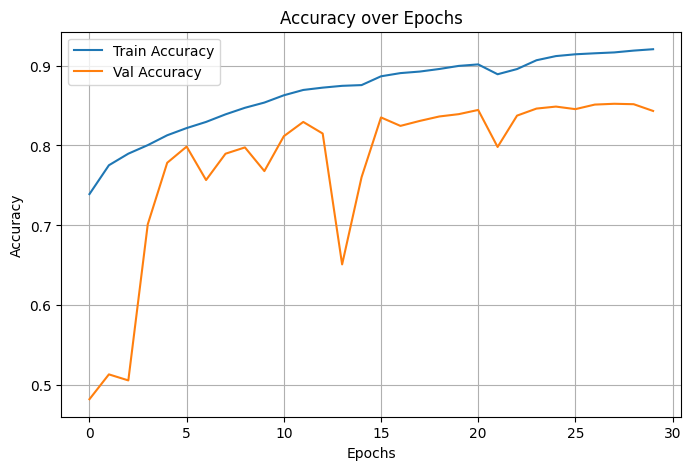

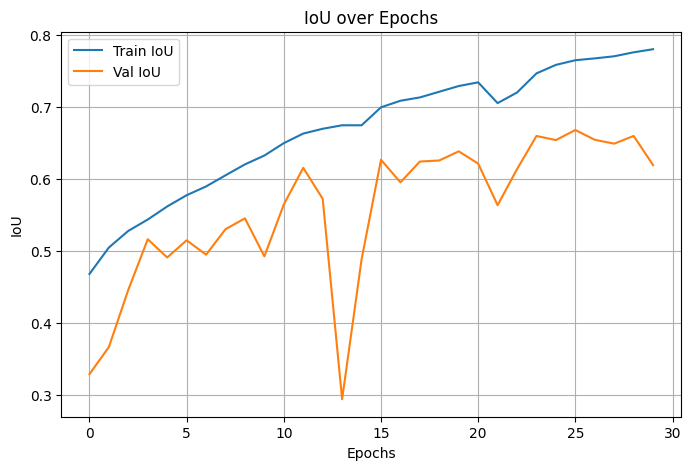

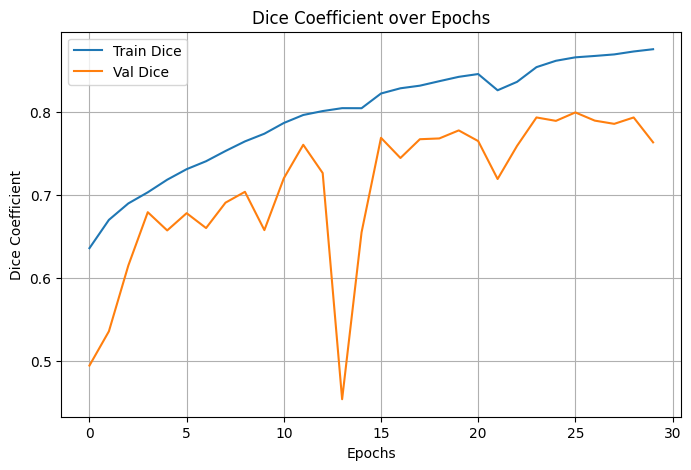

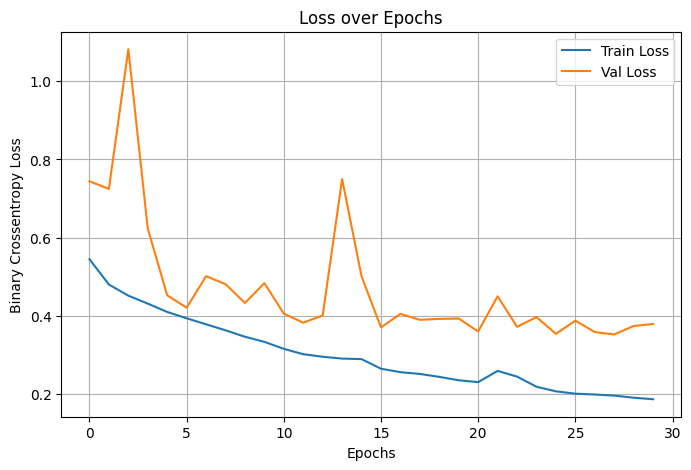

In [ ]:
import matplotlib.pyplot as plt


history_dict = history.history

plt.figure(figsize=(8,5))
plt.plot(history_dict['accuracy'], label='Train Accuracy')
plt.plot(history_dict['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


if 'iou_metric' in history_dict:
    plt.figure(figsize=(8,5))
    plt.plot(history_dict['iou_metric'], label='Train IoU')
    plt.plot(history_dict['val_iou_metric'], label='Val IoU')
    plt.title('IoU over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('IoU')
    plt.legend()
    plt.grid(True)
    plt.show()


if 'dice_coefficient' in history_dict:
    plt.figure(figsize=(8,5))
    plt.plot(history_dict['dice_coefficient'], label='Train Dice')
    plt.plot(history_dict['val_dice_coefficient'], label='Val Dice')
    plt.title('Dice Coefficient over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Dice Coefficient')
    plt.legend()
    plt.grid(True)
    plt.show()


plt.figure(figsize=(8,5))
plt.plot(history_dict['loss'], label='Train Loss')
plt.plot(history_dict['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.grid(True)
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 168ms/step
Classification Report:
              precision    recall  f1-score   support

    No Flood       0.88      0.87      0.88   9133270
       Flood       0.84      0.85      0.85   7250730

    accuracy                           0.86  16384000
   macro avg       0.86      0.86      0.86  16384000
weighted avg       0.86      0.86      0.86  16384000



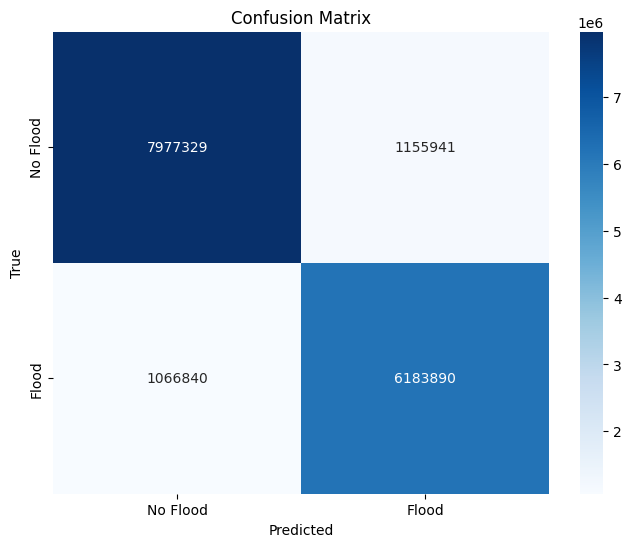

In [ ]:
# 10) Confusion Matrix & Classification Report
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

y_true = y_val.flatten()
y_pred_prob = model.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype(np.uint8).flatten()

# Assuming a binary classification (flood/no flood)
class_names = ["No Flood", "Flood"]

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


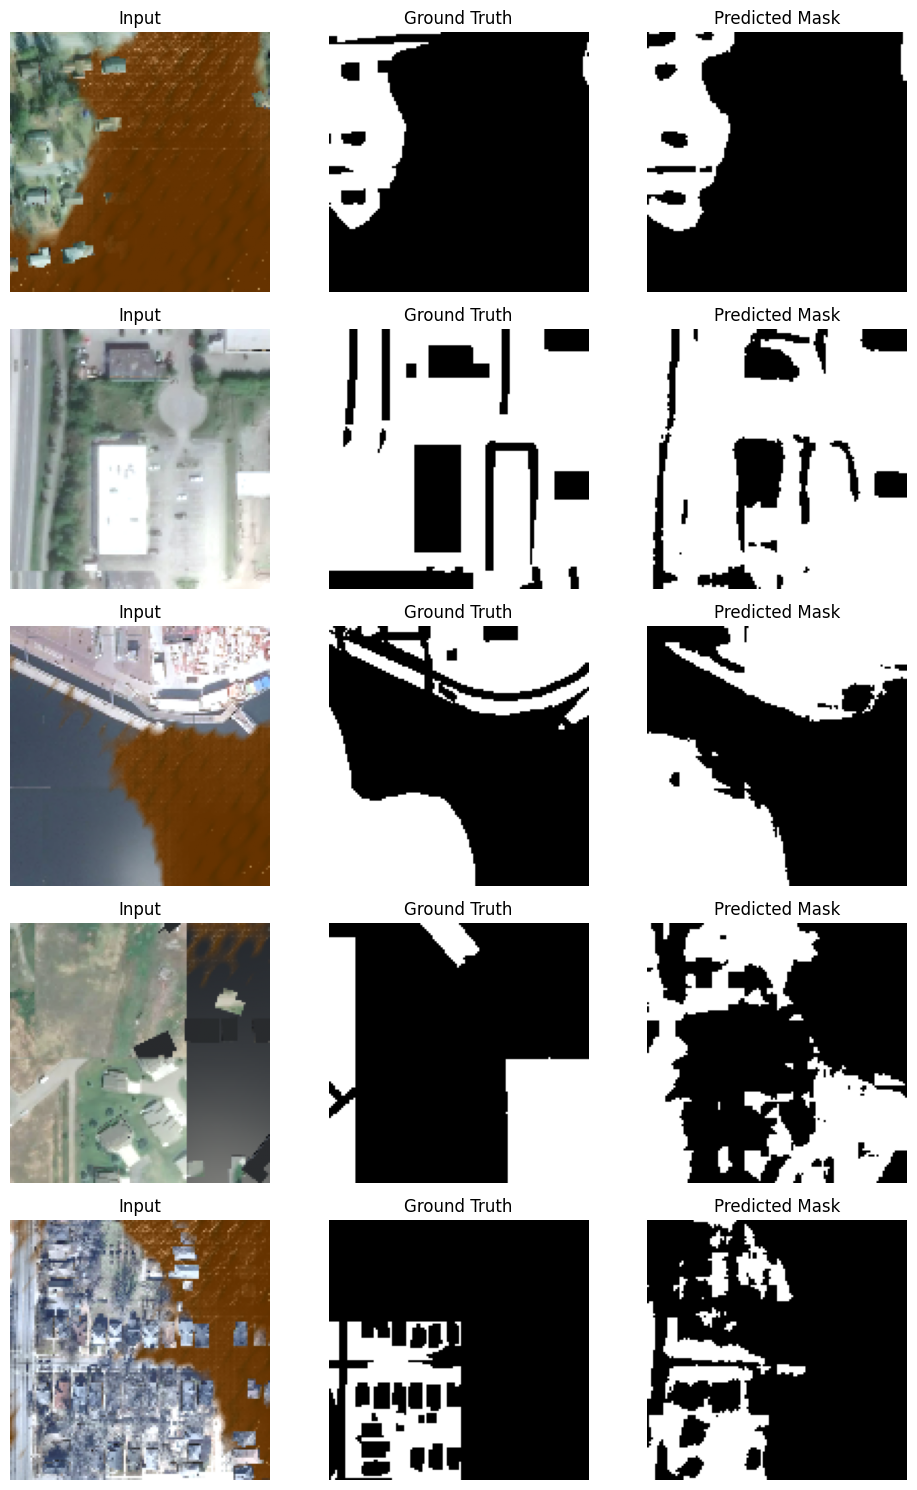

In [ ]:
def visualize_predictions(model, X, y, n=3):
    idx = np.random.choice(len(X), n, replace=False)
    preds = model.predict(X[idx])

    plt.figure(figsize=(10, n * 3))
    for i, j in enumerate(idx):
        plt.subplot(n, 3, i * 3 + 1)
        plt.imshow(X[j])
        plt.title("Input")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 2)
        plt.imshow(y[j].squeeze(), cmap='gray')
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 3)
        plt.imshow(preds[i].squeeze() > 0.5, cmap='gray')
        plt.title("Predicted Mask")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

visualize_predictions(model, X_val, y_val, n=5)